In [1]:
import xarray as xr
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
pip install lightning

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [5]:
ds = xr.open_dataset("../scripts/dataset/earthcare_02529E_LI_19.h5")
ds

<xarray.Dataset> Size: 4MB
Dimensions:                                 (along_track: 255, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 2695 ... ...
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 204kB ...
    ice_mass_flux                           (along_track, height) float32 204kB ...
    ice_effective_radius                    (along_track, height) float32 204kB ...
    ice_median_volume_diameter              (along_track, height) float32 204kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 204kB ...
    spectrum_width_integrated               (along_track, height) float32 204kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 204kB ...
    reflectivity_corrected                  (along_track, height) float32 204kB ...
    multiple_scattering_status              (along_track, height) float64 408kB ...
    simplified_convective_classification    (along_track, height) float64 408kB ...

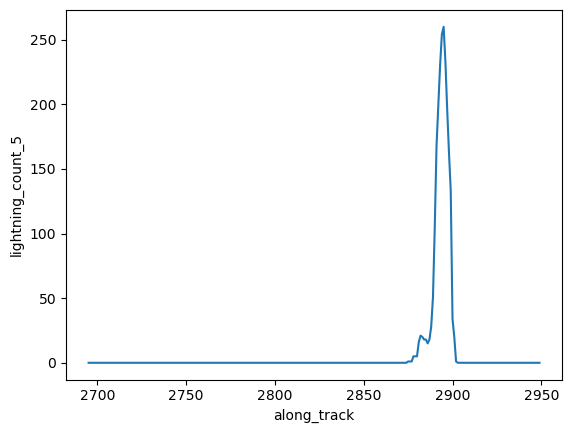

In [6]:
ds.lightning_count_5.plot()

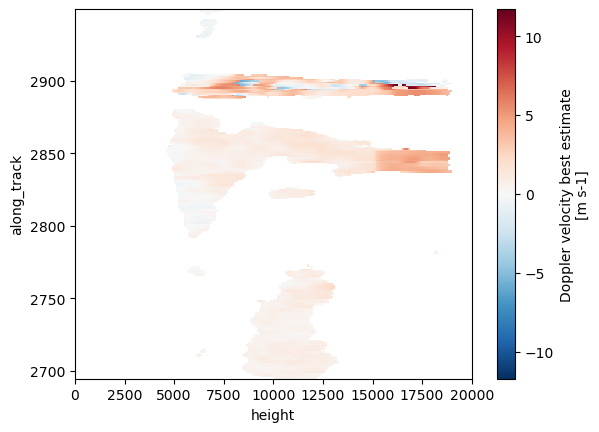

In [8]:
ds.doppler_velocity_best_estimate.plot()

In [9]:
ds.data_vars

Data variables:
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 204kB ...
    ice_mass_flux                           (along_track, height) float32 204kB ...
    ice_effective_radius                    (along_track, height) float32 204kB ...
    ice_median_volume_diameter              (along_track, height) float32 204kB ...
    ice_riming_factor                       (along_track, height) float32 204kB ...
    rain_rate                               (along_track, height) float32 204kB ...
    rain_water_content                      (along_track, height) float32 204kB ...
    rain_median_volume_diameter             (along_track, height) float32 204kB ...
    liquid_water_content                    (along_track, height) float32 204kB ...
    liquid_number_concentration             (along_track, height) float32 204kB ..

## Functions

In [14]:


def compute_input_stats(filepaths, input_vars, output_path):
    output_dict = {
        var: {
            "sum": 0.0,
            "counts": 0,
            "sq_sum": 0.0,
        }
        for var in input_vars
    }

    for file in filepaths:
        ds = read_one_patch(file)
        try:
            for var in input_vars:
                arr = ds[var].values.astype(np.float32)
                mask = np.isfinite(arr)
                valids = arr[mask]

                if valids.size == 0:
                    continue

                output_dict[var]["sum"] += float(valids.sum())
                output_dict[var]["counts"] += int(valids.size)
                output_dict[var]["sq_sum"] += float(np.square(valids).sum())

        finally:
            if hasattr(ds, "close"):
                ds.close()

    for values in output_dict.values():
        values["mean"] = values["sum"] / max(values["counts"], 1)
        var = values["sq_sum"] / max(values["counts"], 1) - values["mean"] ** 2
        values["std"] = float(np.sqrt(max(var, 1e-6)))

        values["sum"] = float(values["sum"])
        values["sq_sum"] = float(values["sq_sum"])
        values["counts"] = int(values["counts"])
        values["mean"] = float(values["mean"])

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(output_dict, f, indent=2)

    return output_dict   
        
                
    

In [23]:
import os 

dataset_path = "../scripts/dataset"
def make_filelist(dataset_path):
    filelist = os.listdir(dataset_path)
    filepaths = []
    for f in filelist:
        if f.endswith(".h5"):
            filepaths.append(f"{dataset_path}/{f}")
        else:
            continue

    return filepaths



In [ ]:
output_path = "../scripts/dataset/stats.json"
import json

compute_input_stats(filepaths,INPUT_VARS,output_path)

In [15]:
def read_one_patch(file):
    return xr.open_dataset(file)

def create_split_filenames():
    return

def load_input_stats(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        stats = json.load(f)
    return stats



In [39]:
from torch.utils.data import Dataset


class EarthCARELightningDataset(Dataset):
    def __init__(
        self,
        filelist,
        input_vars = INPUT_VARS,
        target_vars=TARGET_VARS,
        mean_std_json_path=None,
        fill_value = 0.0
    ):

        self.filelist = filelist
        self.input_vars = input_vars
        self.target_vars = target_vars
        self.stats_dict = load_input_stats(mean_std_json_path)
        self.fill_value = fill_value

    def __len__(self):
        return len(self.filelist)

    def _prepare_input_array(self,
                             ds,
                             var):
        da = ds[var]
        arr = da.transpose("height", "along_track").values.astype(np.float32)

        arr = np.nan_to_num(arr, nan=self.fill_value)
        arr = (arr - self.stats_dict[var]["mean"]) / self.stats_dict[var]["std"]

        return arr

    def _prepare_target_array(self,
                               ds, 
                               var):
        da = ds[var]

        arr = da.transpose("along_track").values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=self.fill_value)

        return arr


        


    def __getitem__(self, ind):
        file_path = self.filelist[ind]
        ds = read_one_patch(file_path)

        try:
            x_channels = []
            y_channels = []
            for var in self.input_vars:
                x_arr = self._prepare_input_array(ds, var)
                x_channels.append(x_arr)

            x = np.stack(x_channels, axis=0)

            for var in self.target_vars:
                y_arr = self._prepare_target_array(ds,var)
                y_channels.append(y_arr)

            y = np.stack(y_channels, axis=0)

            sample = {
                "x": torch.from_numpy(x).float(),
                "y": torch.from_numpy(y).float(),
                "path": str(file_path),
            }

            return sample

        except Exception as e:
            print(e)


In [40]:
from torch.utils.data import DataLoader

def build_dataloaders(
    train_files,
    val_files,
    test_files,
    input_vars,
    target_vars,
    stats_json_path,
    batch_size=8,
    num_workers=0,
    pin_memory=True,
):
    train_ds = EarthCARELightningDataset(
        filelist=train_files,
        input_vars=input_vars,
        target_vars=target_vars,
        mean_std_json_path=stats_json_path,
    )

    val_ds = EarthCARELightningDataset(
        filelist=val_files,
        input_vars=input_vars,
        target_vars=target_vars,
        mean_std_json_path=stats_json_path,
    )

    test_ds = EarthCARELightningDataset(
        filelist=test_files,
        input_vars=input_vars,
        target_vars=target_vars,
        mean_std_json_path=stats_json_path,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

In [32]:
from pathlib import Path
import random
import json

def random_split_dataset(
    dataset_dir,
    train_ratio=0.7,
    val_ratio=0.20,
    test_ratio=0.10,
    seed=42,
):

    dataset_dir = Path(dataset_dir)

    files = make_filelist(dataset_dir)

    rng = random.Random(seed)
    rng.shuffle(files)

    n = len(files)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    split_dict = {
        "train": train_files,
        "val": val_files,
        "test": test_files,
    }

    return split_dict


In [27]:
dataset_path = "../scripts/dataset"

splits_dict = random_split_dataset(dataset_path)
splits_dict

{'train': ['../scripts/dataset/earthcare_02532E_GLM_6.h5',
  '../scripts/dataset/earthcare_02530D_LI_6.h5',
  '../scripts/dataset/earthcare_02530D_LI_4.h5',
  '../scripts/dataset/earthcare_02532E_LI_10.h5',
  '../scripts/dataset/earthcare_02532E_GLM_25.h5',
  '../scripts/dataset/earthcare_02532E_GLM_26.h5',
  '../scripts/dataset/earthcare_02532E_LI_18.h5'],
 'val': ['../scripts/dataset/earthcare_02532E_GLM_19.h5',
  '../scripts/dataset/earthcare_02529E_LI_19.h5'],
 'test': ['../scripts/dataset/earthcare_02529E_LI_3.h5']}

In [41]:
output_path = "../scripts/dataset/train_stats.json"
import json

compute_input_stats(splits_dict['train'],INPUT_VARS,output_path)

{'ice_water_content': {'sum': 49.29638484865427,
  'counts': 357000,
  'sq_sum': 0.17537139891010156,
  'mean': 0.00013808511162088032,
  'std': 0.001},
 'ice_mass_flux': {'sum': 33.777066559530795,
  'counts': 357000,
  'sq_sum': 0.13521357560416902,
  'mean': 9.461363181941399e-05,
  'std': 0.001},
 'ice_effective_radius': {'sum': 6.55983778834343,
  'counts': 109252,
  'sq_sum': 0.0006129889061412541,
  'mean': 6.004318262680252e-05,
  'std': 0.001},
 'ice_median_volume_diameter': {'sum': 94.42339581251144,
  'counts': 109252,
  'sq_sum': 0.8173148684145417,
  'mean': 0.0008642715539533504,
  'std': 0.0025950030229824708},
 'ice_riming_factor': {'sum': 1652.2659454345703,
  'counts': 357000,
  'sq_sum': 230.7120881676674,
  'mean': 0.004628195925587031,
  'std': 0.024996642780240944},
 'rain_rate': {'sum': 11.014477321354207,
  'counts': 187800,
  'sq_sum': 0.011632300206218638,
  'mean': 5.865003898484668e-05,
  'std': 0.001},
 'rain_water_content': {'sum': 2.7809465574100614,
  'c

In [42]:
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader  = build_dataloaders(
    splits_dict['train'],
    splits_dict['val'],
    splits_dict['test'],
    INPUT_VARS,
    TARGET_VARS,
    output_path,
    batch_size=8,
    num_workers=0,
    pin_memory=True,
)

In [48]:
train_ds[0]['x'].shape


torch.Size([20, 200, 255])

In [50]:
batch = next(iter(train_loader))
print(batch["x"].shape)
print(batch["y"].shape)

/opt/conda/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([7, 20, 200, 255])
torch.Size([7, 2, 255])


In [51]:

x = batch["x"]   # [B, C, H, W]

channel_means = x.mean(dim=(0, 2, 3))
channel_stds = x.std(dim=(0, 2, 3))

for i, var in enumerate(INPUT_VARS):
    print(var, "mean=", float(channel_means[i]), "std=", float(channel_stds[i]))

ice_water_content mean= -1.2993478293310545e-08 std= 0.6871464252471924
ice_mass_flux mean= -1.6583781459189595e-08 std= 0.6081108450889587
ice_effective_radius mean= -0.041668277233839035 std= 0.037140581756830215
ice_median_volume_diameter mean= -0.23112890124320984 std= 0.574096143245697
ice_riming_factor mean= -1.7096683180284344e-08 std= 1.0000014305114746
rain_rate mean= -0.027797147631645203 std= 0.17785291373729706
rain_water_content mean= -0.007018259726464748 std= 0.03773517161607742
rain_median_volume_diameter mean= -0.6859990358352661 std= 0.23450076580047607
liquid_water_content mean= -0.009172099642455578 std= 0.1525975614786148
liquid_number_concentration mean= -0.07958479225635529 std= 0.8837023377418518
liquid_effective_radius mean= -0.007249185349792242 std= 0.003356641624122858
aerosol_number_concentration mean= -0.01897311955690384 std= 0.9226759076118469
aerosol_mass_content mean= -3.025380124199728e-07 std= 2.057472556771245e-05
doppler_velocity_best_estimate mean

## Load

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))

from dataset import EarthCARELightningDataset

In [3]:
from datamodule import EarthCARELightningDataModule

In [4]:
dataset_path = "../scripts/dataset"
INPUT_VARS = [
    "ice_water_content",
    "ice_mass_flux",
    "ice_effective_radius",
    "ice_median_volume_diameter",
    "ice_riming_factor",
    "rain_rate",
    "rain_water_content",
    "rain_median_volume_diameter",
    "liquid_water_content",
    "liquid_number_concentration",
    "liquid_effective_radius",
    "aerosol_number_concentration",
    "aerosol_mass_content",
    "doppler_velocity_best_estimate",
    "sedimentation_velocity_best_estimate",
    "spectrum_width_integrated",
    "reflectivity_no_attenuation_correction",
    "reflectivity_corrected",
    "multiple_scattering_status",
    "simplified_convective_classification",
]

TARGET_VARS = [
    "lightning_count_2p5",
    "lightning_count_5",
]

In [5]:
dm = EarthCARELightningDataModule(
    data_dir=dataset_path,
    input_vars=INPUT_VARS,
    target_vars=TARGET_VARS,
    batch_size=8,
    num_workers=0,
    pin_memory=True,
    fill_value=0.0,
    norm_with_train=True,
    
)

dm.setup()

batch = next(iter(dm.train_dataloader()))
print(batch["x"].shape)
print(batch["y"].shape)

/opt/conda/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([7, 20, 200, 255])
torch.Size([7, 2, 255])
